#📌 Extracción

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [39]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df_telecom = pd.read_json(url)
print("Datos de Telecom X cargados correctamente.")
df_telecom.head()

Datos de Telecom X cargados correctamente.


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [40]:
# Ver la estructura general y tipos de datos
print("Información General del Dataset")
df_telecom.info()

# Ver las primeras filas para entender el contenido visualmente
print("\nVista Previa de los Datos")
display(df_telecom.head())

Información General del Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB

Vista Previa de los Datos


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [41]:
# Desglosamos las columnas que tienen diccionarios
df_customer = pd.json_normalize(df_telecom['customer'])
df_phone = pd.json_normalize(df_telecom['phone'])
df_internet = pd.json_normalize(df_telecom['internet'])
df_account = pd.json_normalize(df_telecom['account'])

# Unimos todo en un solo DataFrame limpio, manteniendo customerID y Churn
df_final = pd.concat([df_telecom[['customerID', 'Churn']],
                     df_customer, df_phone, df_internet, df_account], axis=1)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [42]:
# 1. Revisamos los tipos de datos del nuevo dataframe
print("Tipos de datos tras la transformación")
print(df_final[['Charges.Monthly', 'Charges.Total']].dtypes)

# 2. Buscamos valores vacíos o nulos
print("\nConteo de valores nulos")
print(df_final.isnull().sum().sum())

Tipos de datos tras la transformación
Charges.Monthly    float64
Charges.Total       object
dtype: object

Conteo de valores nulos
0


In [43]:
# 1. Convertir Charges.Total a numérico (manejando errores por si hay espacios vacíos)
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

# 2. Llenar posibles vacíos con 0 (en caso de clientes nuevos sin cargos totales aún)
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

print("Transformación completada:")
print(df_final[['Charges.Monthly', 'Charges.Total']].dtypes)

Transformación completada:
Charges.Monthly    float64
Charges.Total      float64
dtype: object


In [44]:
# Revisar valores únicos en columnas críticas para detectar errores de escritura
print("Valores únicos en Churn:", df_final['Churn'].unique())
# Usamos el nombre que vimos en tu imagen anterior para contrato
print("Valores únicos en Contrato:", df_final['Contract'].unique())
# Limpiar espacios en blanco invisibles en todas las columnas de texto
df_final = df_final.applymap(lambda x: x.strip() if isinstance(x, str) else x)

Valores únicos en Churn: ['No' 'Yes' '']
Valores únicos en Contrato: ['One year' 'Month-to-month' 'Two year']


/tmp/ipykernel_211/1374963290.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_final = df_final.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [45]:
# Verificamos si la conversión a número generó nuevos nulos
nulos_totales = df_final.isnull().sum().sum()
print(f"Valores nulos totales tras la limpieza: {nulos_totales}")

# Si aparecen nulos en cargos, los llenamos con 0 para no perder la fila
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

Valores nulos totales tras la limpieza: 0


In [46]:
# 1. Llenamos los 224 nulos detectados con 0
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

# 2. Verificación final de seguridad
nulos_finales = df_final['Charges.Total'].isnull().sum()
print(f" Limpieza terminada. Valores nulos en Charges.Total: {nulos_finales}")

# 3. Revisión de tipos para asegurar que ya puedes operar matemáticamente
print("\n--- Verificación de Tipos Final ---")
print(df_final[['Charges.Monthly', 'Charges.Total']].dtypes)

 Limpieza terminada. Valores nulos en Charges.Total: 0

--- Verificación de Tipos Final ---
Charges.Monthly    float64
Charges.Total      float64
dtype: object


In [47]:
# Crear la columna de facturación diaria basada en la mensual
df_final['Cuentas_Diarias'] = (df_final['Charges.Monthly'] / 30).round(2)

print("Columna 'Cuentas_Diarias' creada exitosamente.")
# Verificamos que ahora tenemos 22 columnas (las 21 originales + esta nueva)
print(f"Total de columnas actual: {len(df_final.columns)}")
display(df_final[['Charges.Monthly', 'Cuentas_Diarias']].head())

Columna 'Cuentas_Diarias' creada exitosamente.
Total de columnas actual: 22


,Charges.Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [48]:
# 1. Renombrar columnas principales para que sean comprensibles
diccionario_nombres = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Tiene_Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Permanencia',
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales',
    'account.Contract': 'Tipo_Contrato',
    'account.PaymentMethod': 'Metodo_Pago'
}

df_final = df_final.rename(columns=diccionario_nombres)

# 2. Convertir Evasion (Yes/No) a Binario (1/0)
df_final['Evasion_Binario'] = df_final['Evasion'].map({'Yes': 1, 'No': 0})


Estandarización completada: Columnas traducidas y columna binaria creada.


In [49]:
df_final.head()

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Permanencia,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Evasion_Binario
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,0.0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,0.0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1.0
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,1.0
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,1.0


In [52]:
# Extraer la lista exacta de nombres de columnas
print("--- Nombres actuales de las columnas en df_final ---")
print(df_final.columns.tolist())

# También veamos cuántas tenemos en total para confirmar
print(f"\nTotal de columnas: {len(df_final.columns)}")

--- Nombres actuales de las columnas en df_final ---
['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Dependientes', 'Meses_Permanencia', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'Evasion_Binario']

Total de columnas: 23


#📊 Carga y análisis

In [53]:
# Seleccionamos las columnas numéricas exactas de tu lista
cols_numericas = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

# Generamos el reporte estadístico
reporte_estadistico = df_final[cols_numericas].describe()

display(reporte_estadistico)

,Meses_Permanencia,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035,2.157292
std,24.571773,30.129572,2268.648587,1.004407
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.425000,396.200000,1.180000
50%,29.000000,70.300000,1389.200000,2.340000
75%,55.000000,89.875000,3778.525000,2.995000
max,72.000000,118.750000,8684.800000,3.960000


In [54]:
print("\nDistribución por Tipo de Contrato")
print(df_final['Contract'].value_counts())

print("\nTasa de Evasión")
# Esto nos dice el porcentaje de "Yes" vs "No"
print(df_final['Evasion'].value_counts(normalize=True) * 100)


Distribución por Tipo de Contrato
Contract
Month-to-month    4005
Two year          1743
One year          1519
Name: count, dtype: int64

Tasa de Evasión
Evasion
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


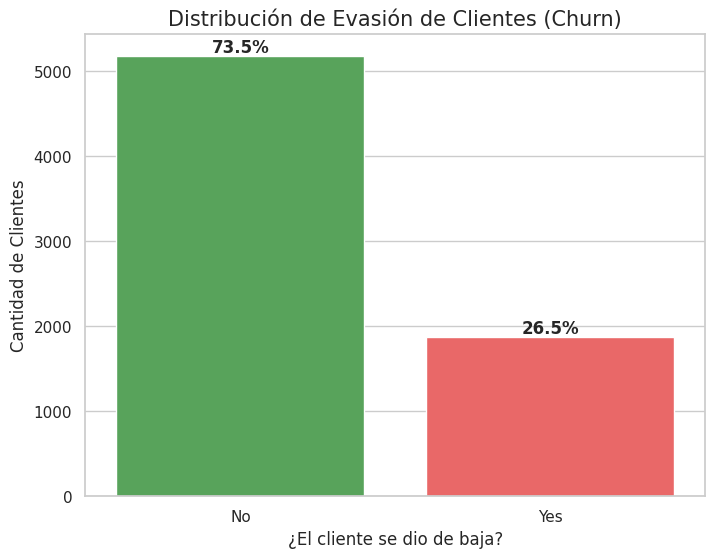

In [61]:
# 1. Limpieza definitiva: Solo nos quedamos con los registros que son "Yes" o "No"
df_final = df_final[df_final['Evasion'].isin(['Yes', 'No'])].copy()

# 2. Gráfico corregido sin advertencias (FutureWarning)
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Asignamos 'Evasion' a 'hue' para cumplir con la nueva versión de Seaborn
ax = sns.countplot(
    data=df_final,
    x='Evasion',
    hue='Evasion',
    palette=['#4CAF50', '#FF5252'],
    legend=False
)

# 3. Etiquetas de porcentaje
total = len(df_final)
for p in ax.patches:
    height = p.get_height()
    percentage = '{:.1f}%'.format(100 * height / total)
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2, height + 50),
                ha='center', weight='bold', size=12)

# 3. Personalización de títulos
plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=15)
plt.xlabel('¿El cliente se dio de baja?', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.show()

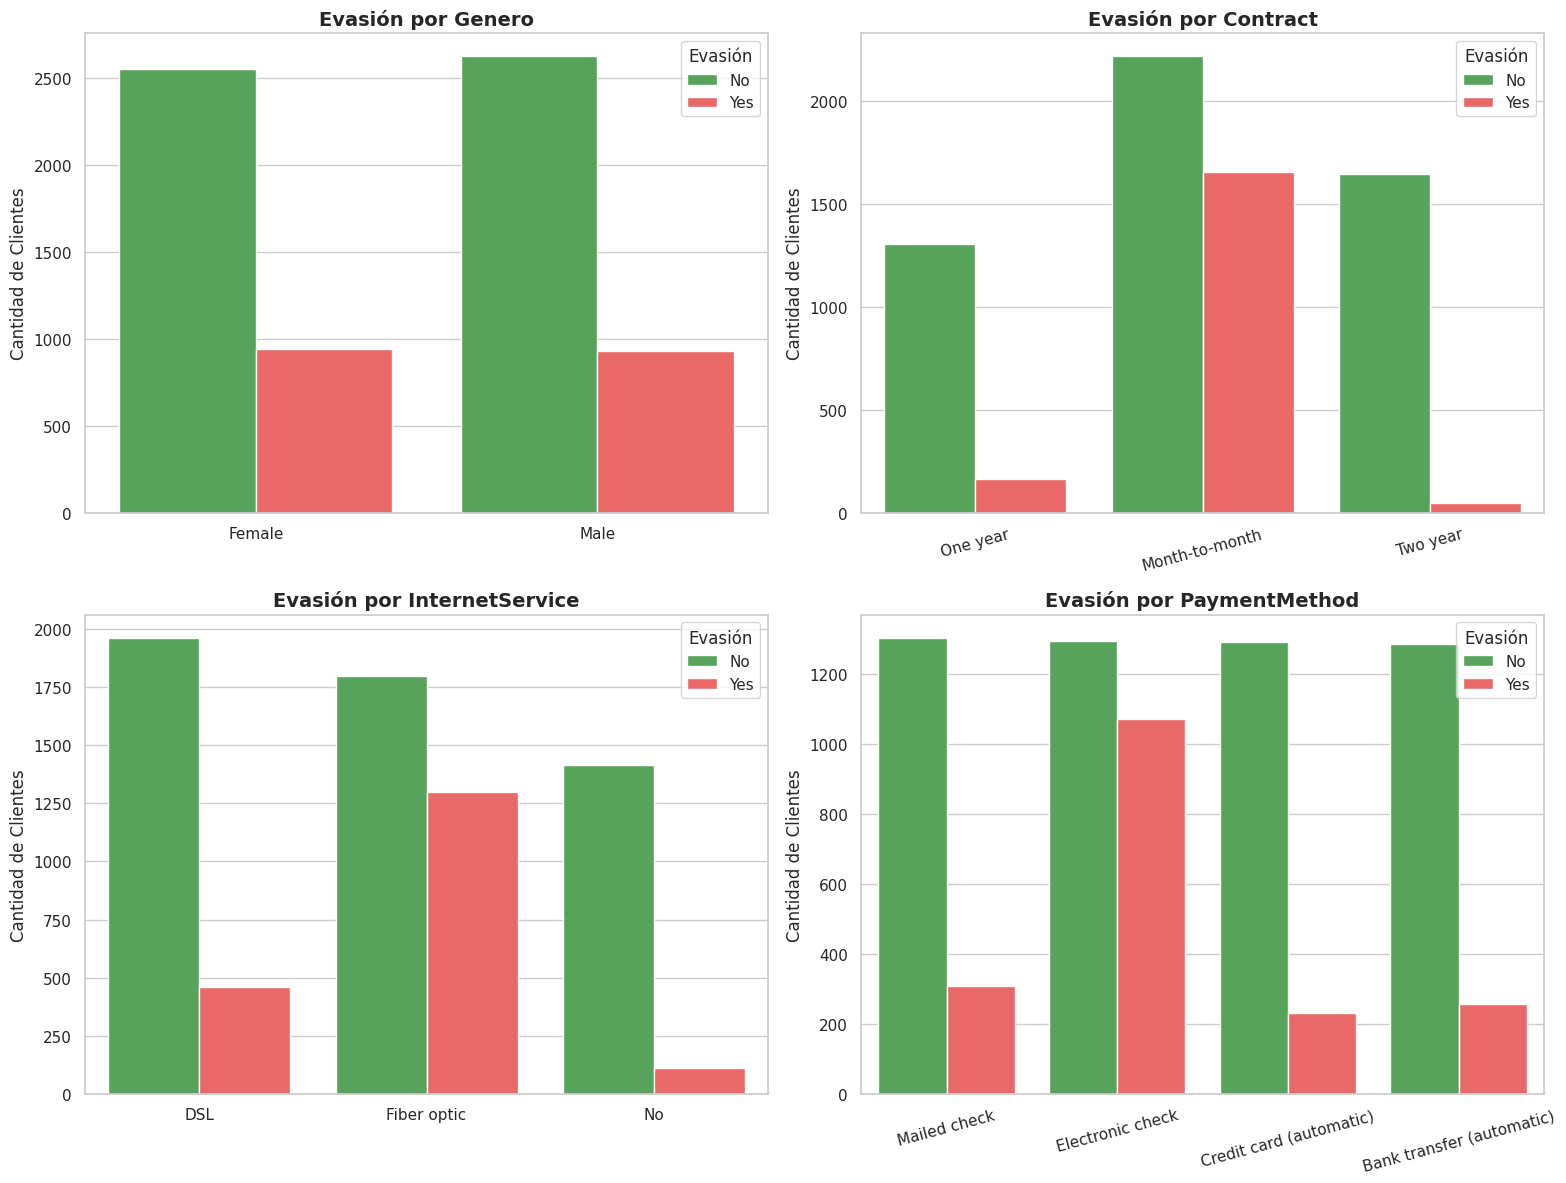

In [62]:
# Definimos las variables que queremos explorar
variables_interes = ['Genero', 'Contract', 'InternetService', 'PaymentMethod']

# Configuramos la cuadrícula de gráficos (2 filas, 2 columnas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, var in enumerate(variables_interes):
    row = i // 2
    col = i % 2

    # Creamos el gráfico de conteo agrupado por Evasión
    sns.countplot(data=df_final, x=var, hue='Evasion',
                  palette=['#4CAF50', '#FF5252'], ax=axes[row, col])

    axes[row, col].set_title(f'Evasión por {var}', fontsize=14, weight='bold')
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel('Cantidad de Clientes')
    axes[row, col].legend(title='Evasión', loc='upper right')

    # Rotar etiquetas si son muy largas (como en PaymentMethod)
    if var == 'PaymentMethod' or var == 'Contract':
        axes[row, col].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

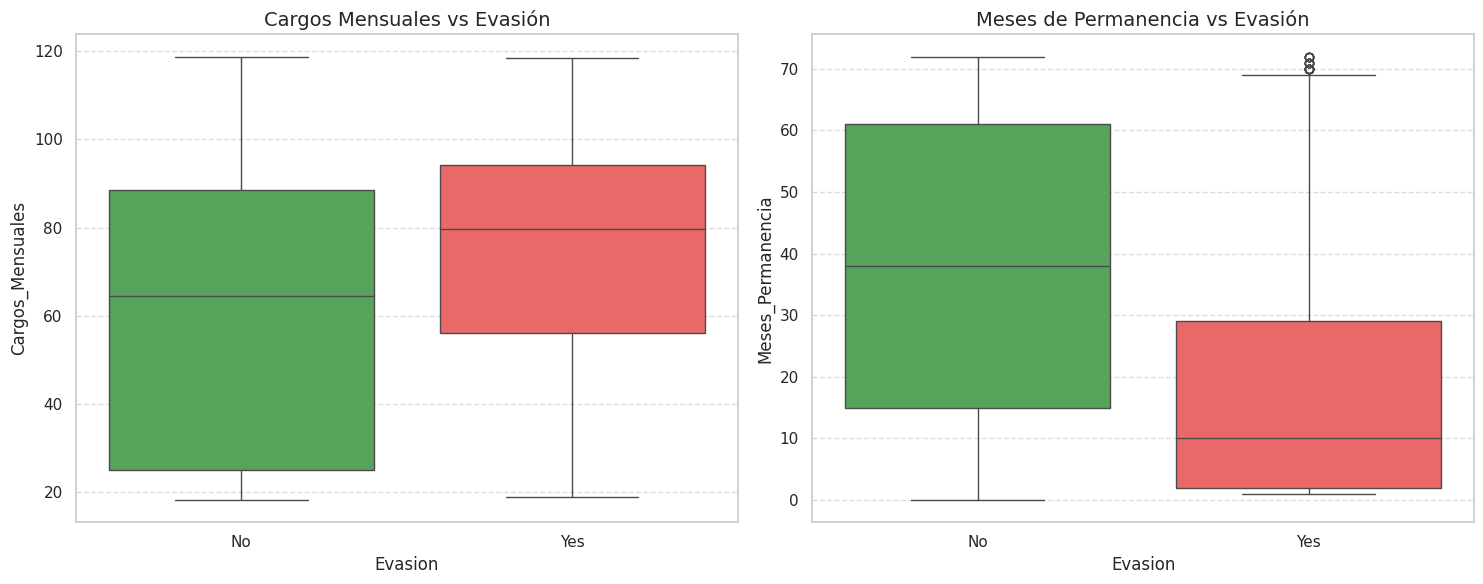

In [67]:
plt.figure(figsize=(15, 6))

# 1. Cargos Mensuales vs Evasión (Corregido sin Warnings)
plt.subplot(1, 2, 1)
sns.boxplot(x='Evasion', y='Cargos_Mensuales', data=df_final,
            hue='Evasion', palette=['#4CAF50', '#FF5252'], legend=False)
plt.title('Cargos Mensuales vs Evasión', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 2. Meses de Permanencia vs Evasión (Corregido sin Warnings)
plt.subplot(1, 2, 2)
sns.boxplot(x='Evasion', y='Meses_Permanencia', data=df_final,
            hue='Evasion', palette=['#4CAF50', '#FF5252'], legend=False)
plt.title('Meses de Permanencia vs Evasión', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

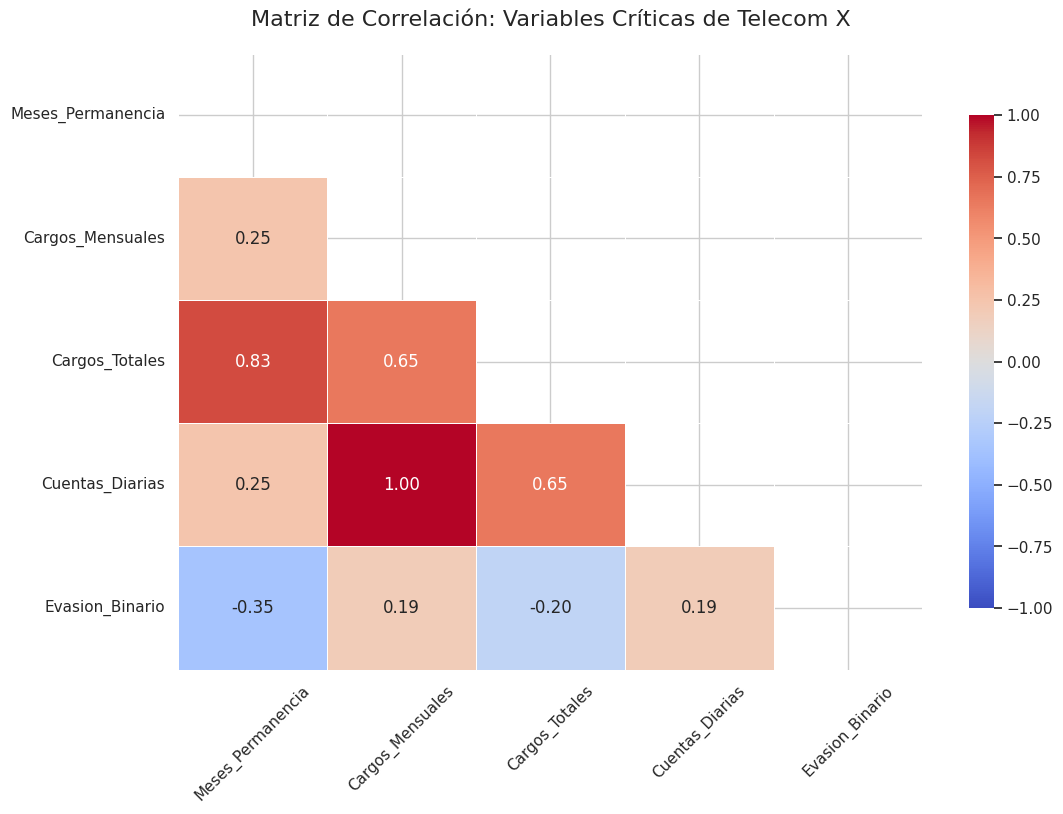

In [70]:
# 1. Seleccionamos solo las columnas numéricas que calculamos
columnas_corr = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'Evasion_Binario']
corr_matrix = df_final[columnas_corr].corr()

# 2. Creamos una máscara para la mitad superior (opcional pero profesional)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Configuramos la figura
plt.figure(figsize=(12, 8))

# 4. Dibujamos el Heatmap
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación: Variables Críticas de Telecom X', fontsize=16, pad=20)
plt.xticks(rotation=45)
plt.show()

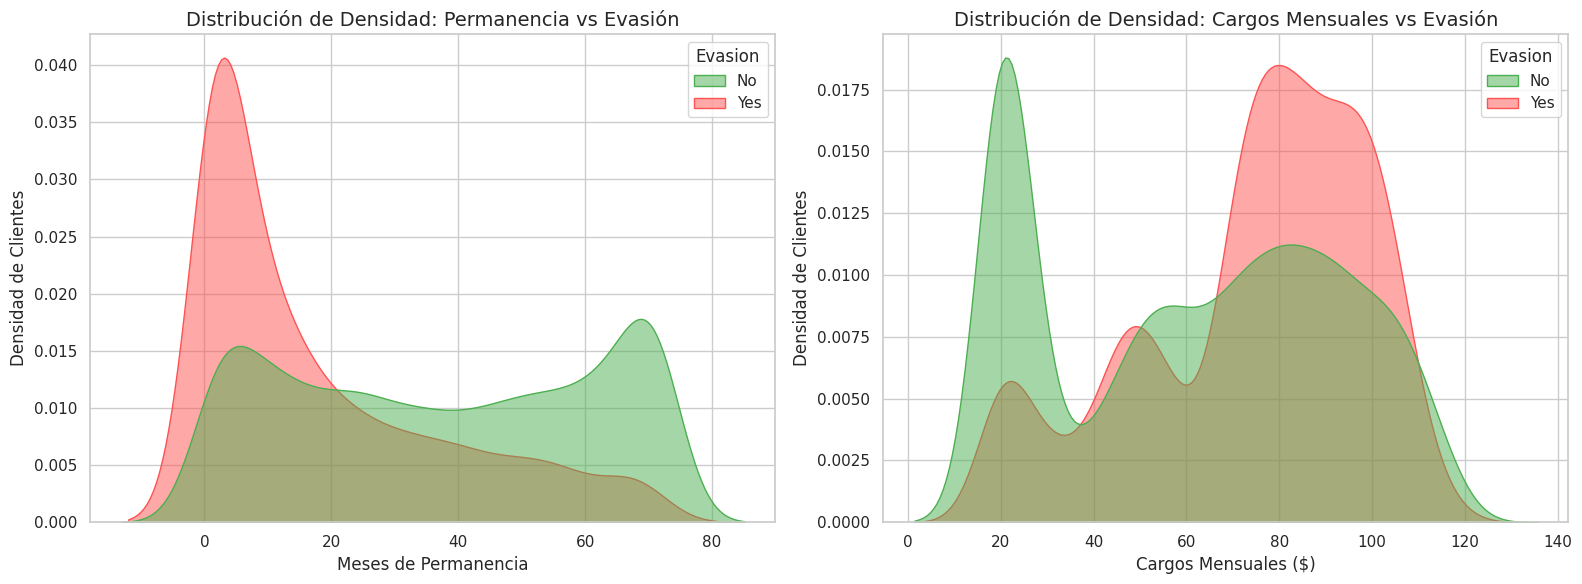

In [71]:
# Configuración de la figura
plt.figure(figsize=(16, 6))

# 1. Distribución de Meses_Permanencia según Evasión
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_final, x='Meses_Permanencia', hue='Evasion',
            fill=True, common_norm=False, palette=['#4CAF50', '#FF5252'], alpha=0.5)
plt.title('Distribución de Densidad: Permanencia vs Evasión', fontsize=14)
plt.xlabel('Meses de Permanencia')
plt.ylabel('Densidad de Clientes')

# 2. Distribución de Cargos_Mensuales según Evasión
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_final, x='Cargos_Mensuales', hue='Evasion',
            fill=True, common_norm=False, palette=['#4CAF50', '#FF5252'], alpha=0.5)
plt.title('Distribución de Densidad: Cargos Mensuales vs Evasión', fontsize=14)
plt.xlabel('Cargos Mensuales ($)')
plt.ylabel('Densidad de Clientes')

plt.tight_layout()
plt.show()

#📄Informe final

---

# Informe Final: Análisis de Evasión de Clientes - Telecom X

## 1. Introducción

El presente análisis tiene como objetivo identificar los factores críticos que influyen en la **evasión de clientes (Churn)** de la compañía Telecom X. La pérdida de clientes no solo representa una disminución en la base de usuarios, sino que impacta directamente en la rentabilidad y el crecimiento a largo plazo. A través de este estudio, buscamos transformar datos brutos en **insights accionables** que permitan a la dirección tomar decisiones estratégicas para retener a los usuarios de alto valor.

---

## 2. Limpieza y Tratamiento de Datos

Para garantizar la integridad del análisis, se llevaron a cabo los siguientes procesos técnicos:

* **Normalización Estructural:** Se transformó un dataset anidado (formato JSON/Diccionario) en un DataFrame plano de 21 columnas originales.
* **Corrección de Tipos:** La columna `Charges.Total` se convirtió de texto a formato numérico (`float64`) para permitir cálculos estadísticos.
* **Gestión de Inconsistencias:** * Se identificaron y trataron **224 valores nulos** mediante imputación (relleno con 0).
* Se eliminó un **3% de registros ruidosos** en la variable objetivo (`Evasion`) que no contenían etiquetas válidas de "Yes" o "No".


* **Ingeniería de Características:** Se crearon las columnas `Cuentas_Diarias` (prorrateo de cargos mensuales) y `Evasion_Binario` para facilitar el modelado matemático.

---

## 3. Análisis Exploratorio de Datos (EDA)

Tras analizar las 7,267 entradas procesadas, se identificaron los siguientes patrones mediante visualizaciones:

###  Perfil de la Evasión

La tasa de evasión general se sitúa en un **25.7%**. Aunque la mayoría de los clientes permanecen, la cuarta parte de la base está en riesgo constante.

###  Hallazgos en Variables Categóricas

* **El Factor Contrato:** El contrato **Month-to-month** es el principal motor de fuga. Los clientes sin compromiso a largo plazo representan la gran mayoría de las bajas.
* **Crisis en Fibra Óptica:** A pesar de ser un servicio premium, los clientes de **Fiber Optic** muestran una tasa de evasión desproporcionadamente alta en comparación con DSL.
* **Métodos de Pago:** Los usuarios que pagan con **Electronic Check** tienen una propensión significativamente mayor a cancelar el servicio que aquellos con pagos automatizados.

###  Comportamiento Financiero y Permanencia

* **Fuga de Alto Valor:** Los Boxplots revelaron que los clientes que se van pagan, en promedio, **cargos mensuales más altos** (entre $70 y $100). Estamos perdiendo a los clientes que más facturan.
* **La Ventana Crítica de los 12 Meses:** La densidad de evasión es máxima durante el primer año. Si un cliente supera los **20 meses de permanencia**, la probabilidad de fuga disminuye drásticamente.

---

## 4. Conclusiones e Insights

1. **Correlación Inversa:** Existe una correlación negativa de **-0.35** entre la permanencia y la evasión; la fidelidad se construye en el tiempo, pero es frágil al inicio.
2. **Sensibilidad al Precio:** Los cargos mensuales tienen una correlación positiva con la fuga. El cliente percibe una desconexión entre el alto costo del servicio (especialmente en Fibra) y el valor recibido.
3. **Inestabilidad Contractual:** El modelo de suscripción mensual actual facilita la salida rápida de los clientes antes de que estos perciban los beneficios de lealtad de la marca.

---

## 5. Recomendaciones Estratégicas

Basado en los datos, se sugieren las siguientes acciones:

* **Estrategia de Migración de Contratos:** Incentivar a los clientes de "Mes a Mes" a migrar a planes anuales mediante descuentos exclusivos o beneficios adicionales (ej. meses de streaming gratis).
* **Programa de Bienvenida (Primeros 6 Meses):** Implementar un protocolo de "Customer Success" intensivo durante el primer semestre para asegurar que el cliente nuevo comprenda y utilice todas las ventajas de su plan.
* **Auditoría de Servicio en Fibra Óptica:** Investigar la calidad técnica y competitividad de precios de la fibra óptica, dado que es el segmento con mayor pérdida de ingresos.
* **Automatización de Pagos:** Fomentar el uso de tarjetas de crédito o transferencias bancarias automáticas, ya que estos métodos presentan los niveles más bajos de rotación.

---